In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

df = pd.read_csv("/kaggle/input/datasets/uciml/iris/Iris.csv")
print(df.head())

   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa


In [2]:
print(df["Species"].value_counts())

Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


In [3]:
print(df.isnull().sum())
print(df.isna().sum())
print("Количество дубликатов:", df.duplicated().sum())

Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64
Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64
Количество дубликатов: 0


In [4]:
df = df.drop(columns=["Id"])

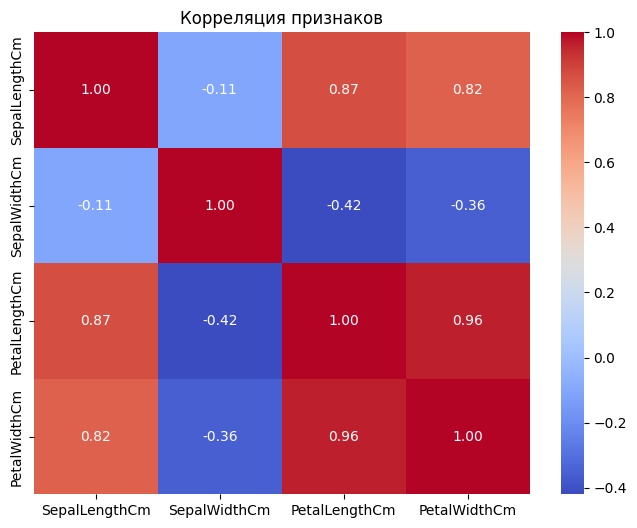

In [5]:
X = df.drop(columns=["Species"])
y = df["Species"]

plt.figure(figsize=(8, 6))

sns.heatmap(
    X.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Корреляция признаков")
plt.show()

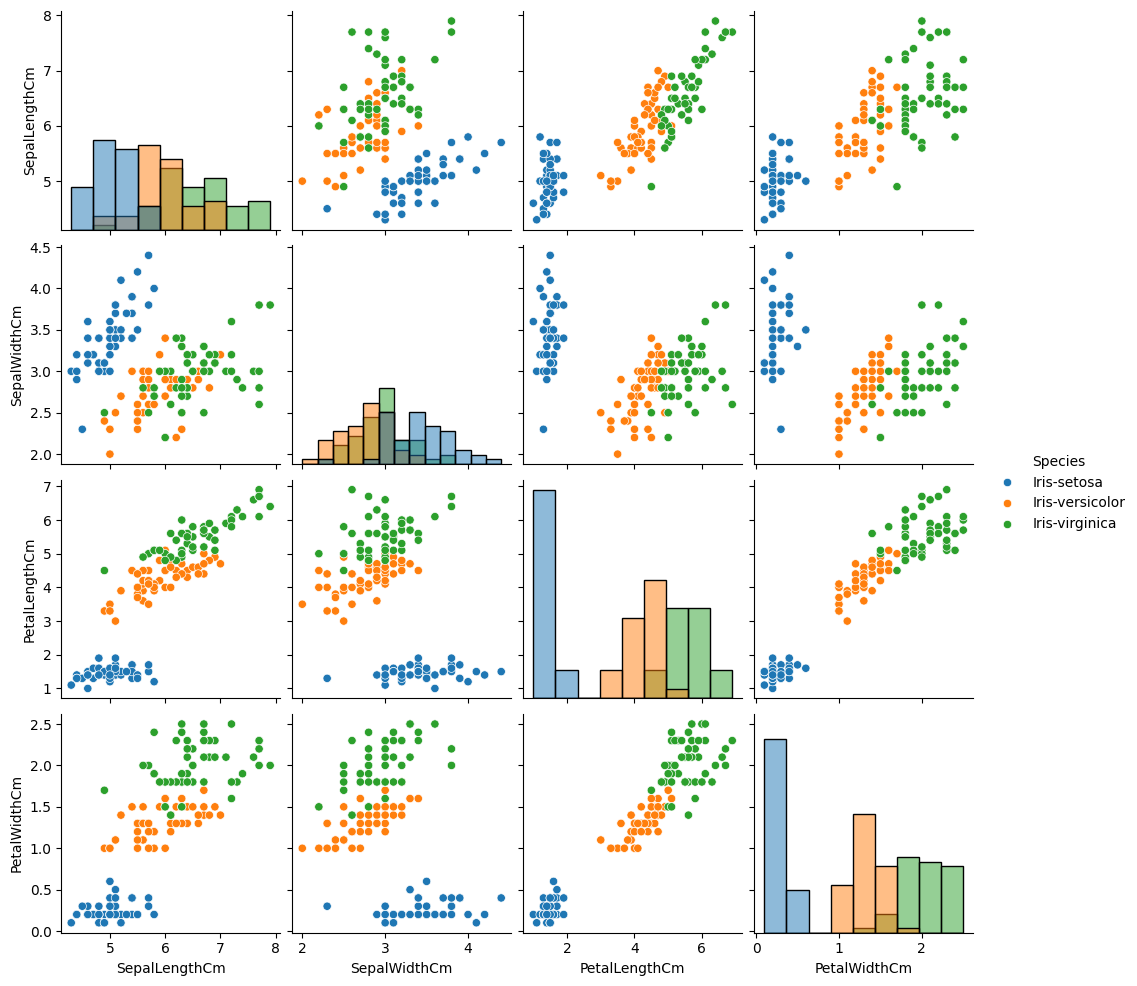

In [6]:
sns.pairplot(
    df,
    hue="Species",
    diag_kind="hist"
)

plt.show()

Уже здесь видна очень хорошая кластеризация. Выполню небольшой сайд-квест и попробую разделить виды простым PCA.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [8]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [9]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

pca_df = pd.DataFrame(
    X_train_pca,
    columns=["PC1", "PC2"]
)

pca_df["Species"] = y_train.values

print(pca_df.head())

        PC1       PC2          Species
0 -2.362868 -1.007809      Iris-setosa
1  0.317467 -1.482384   Iris-virginica
2  1.226343 -0.094959  Iris-versicolor
3 -2.199332 -0.388537      Iris-setosa
4  0.232576 -1.277702  Iris-versicolor


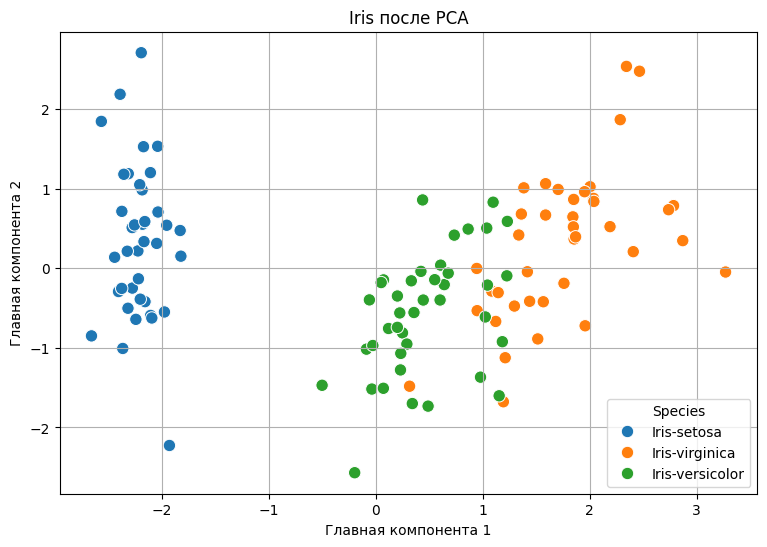

In [10]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Species",
    s=80
)

plt.title("Iris после PCA")
plt.xlabel("Главная компонента 1")
plt.ylabel("Главная компонента 2")
plt.grid(True)
plt.show()

Ладно, если честно, не настолько чистые кластеры, как я ожидала. Хотя это все равно отличный результат. Тем не менее, возвращаемся к KNN.

Надо подобрать оптимальный k. Т.к. датасет маленький, подбирать можно тупым перебором: от 1 до 50, где 50 - это количество объектов класса.

In [11]:
k_values = range(1, 51)

accuracy_scores = []

for k in k_values:
    model = KNeighborsClassifier(
        n_neighbors=k
    )

    model.fit(X_train_scaled, y_train)

    y_pred = model.predict(X_test_scaled)

    accuracy_scores.append(
        accuracy_score(y_test, y_pred)
    )

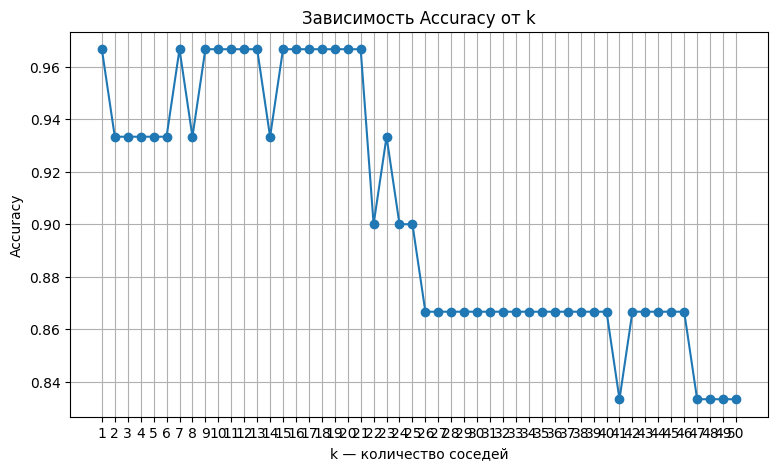

In [12]:
plt.figure(figsize=(9, 5))

plt.plot(
    k_values,
    accuracy_scores,
    marker="o"
)

plt.xlabel("k — количество соседей")
plt.ylabel("Accuracy")
plt.title("Зависимость Accuracy от k")

plt.xticks(k_values)
plt.grid(True)

plt.show()

После 21 соседа аккуратность резко падает. Но выбрать между k от 1 до 20, которые дают одинаковые результаты, все еще трудно. Можно в целом тыкать наобум, но я попробую сделать кросс-валидацию.

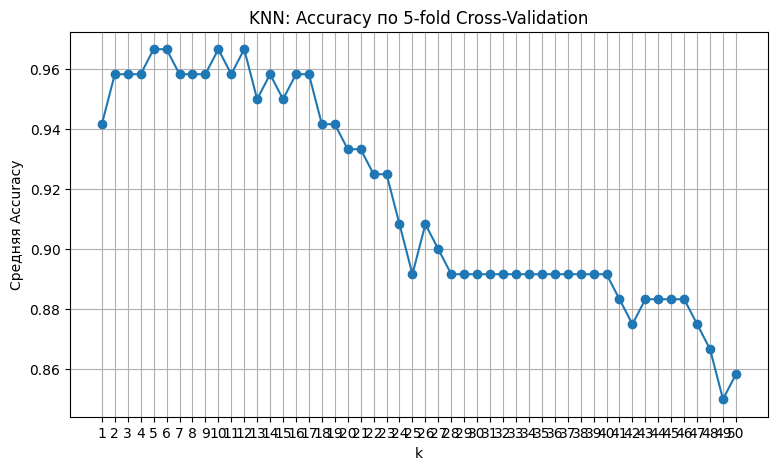

In [13]:
from sklearn.model_selection import cross_val_score

k_values = range(1, 51)

cv_scores = []

for k in k_values:
    model = KNeighborsClassifier(
        n_neighbors=k
    )

    scores = cross_val_score(
        model,
        X_train_scaled,
        y_train,
        cv=5,
        scoring="accuracy"
    )

    cv_scores.append(scores.mean())

plt.figure(figsize=(9, 5))

plt.plot(
    k_values,
    cv_scores,
    marker="o"
)

plt.xlabel("k")
plt.ylabel("Средняя Accuracy")
plt.title("KNN: Accuracy по 5-fold Cross-Validation")
plt.xticks(k_values)
plt.grid(True)

plt.show()

Все еще огромный диапазон допустимого k. Данные слишком хороши. Колебания в пределах случайности. Если честно, тут можно было бы вручную расставить пороги по признакам и получить нормальную классификацию, но раз уж взялись, то пусть будет k = 10.

In [14]:
best_k = 10

knn_best = KNeighborsClassifier(
    n_neighbors=best_k
)

knn_best.fit(X_train_scaled, y_train)

y_pred_best = knn_best.predict(X_test_scaled)

Попробуем также weighted, не отходя от кассы. Считать вес будем от дистанции: ближе сосед - больше вес.

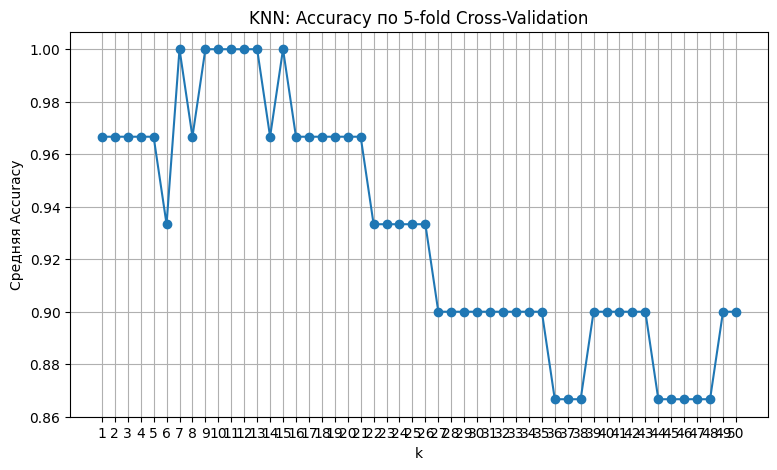

In [15]:
weighted_accuracy_scores = []

for k in k_values:
    model = KNeighborsClassifier(
        n_neighbors=k,
        weights="distance"
    )

    model.fit(X_train_scaled, y_train)

    y_pred = model.predict(X_test_scaled)

    weighted_accuracy_scores.append(
        accuracy_score(y_test, y_pred)
    )

plt.figure(figsize=(9, 5))

plt.plot(
    k_values,
    weighted_accuracy_scores,
    marker="o"
)

plt.xlabel("k")
plt.ylabel("Средняя Accuracy")
plt.title("KNN: Accuracy по 5-fold Cross-Validation")
plt.xticks(k_values)
plt.grid(True)

plt.show()

Легким движением руки, мы добились accuracy = 1.0. В другой ситуации я бы сказала, что это утечка, но нет, это датасет такой.

In [16]:
knn_final = KNeighborsClassifier(
    n_neighbors=best_k
)

knn_weighted_final = KNeighborsClassifier(
    n_neighbors=best_k,
    weights="distance"
)

knn_final.fit(X_train_scaled, y_train)
knn_weighted_final.fit(X_train_scaled, y_train)

pred_knn = knn_final.predict(X_test_scaled)
pred_weighted = knn_weighted_final.predict(X_test_scaled)

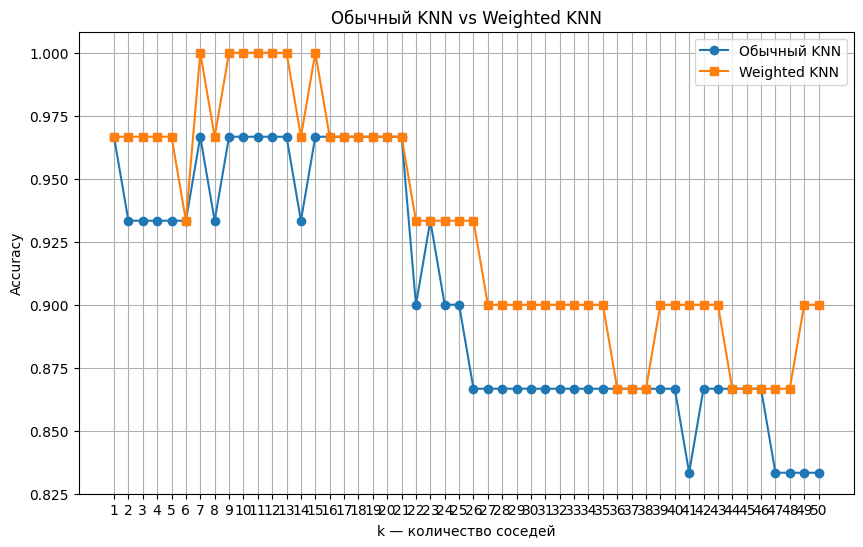

In [17]:
plt.figure(figsize=(10, 6))

plt.plot(
    k_values,
    accuracy_scores,
    marker="o",
    label="Обычный KNN"
)

plt.plot(
    k_values,
    weighted_accuracy_scores,
    marker="s",
    label="Weighted KNN"
)

plt.xlabel("k — количество соседей")
plt.ylabel("Accuracy")
plt.title("Обычный KNN vs Weighted KNN")

plt.xticks(k_values)
plt.grid(True)
plt.legend()

plt.show()